## Insider Threat Radar – Behavior Analytics for Employee Risk Prediction

### Anomaly Detection (Unsupervised) 

#### Import Libraries

In [1]:
import pandas as pd
import numpy as np

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

#### Load Feature Data

In [2]:
data = pd.read_csv("../Dataset/final_features.csv")
print(data.shape)
data.head()

(1000, 13)


,user,total_emails,total_attachments,avg_email_size,off_hour_emails,weekend_emails,employee_name,user_id,O,C,E,A,N
0,AAE0190,4711,1780,30020.394184,499,0,August Armando Evans,AAE0190,36,30,14,50,29
1,AAF0535,480,364,30397.402083,1,0,Athena Amelia Foreman,AAF0535,17,21,36,33,31
2,AAF0791,3012,0,29958.497676,377,0,Aladdin Abraham Foley,AAF0791,14,40,40,50,34
3,AAL0706,336,145,29828.181548,54,0,April Alika Levy,AAL0706,37,14,28,13,25
4,AAM0658,659,613,29895.532625,146,0,Abel Adam Morton,AAM0658,43,35,37,36,22


#### Select Feature Columns

In [3]:
feature_cols = [
    'total_emails',
    'total_attachments',
    'avg_email_size',
    'off_hour_emails',
    'weekend_emails',
    'O','C','E','A','N'
]

X = data[feature_cols]

#### Scale Features

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#### Train Isolation Forest

In [5]:
iso_model = IsolationForest(
    n_estimators=100,
    contamination=0.02,
    random_state=42
)

iso_model.fit(X_scaled)

IsolationForest(contamination=0.02, random_state=42)

#### Predict Anomalies

In [6]:
data['anomaly_label'] = iso_model.predict(X_scaled)

# -1 = anomaly, 1 = normal
data['anomaly_flag'] = data['anomaly_label'].apply(
    lambda x: 1 if x == -1 else 0
)

data[['user','anomaly_flag']].head()

,user,anomaly_flag
0,AAE0190,0
1,AAF0535,0
2,AAF0791,0
3,AAL0706,0
4,AAM0658,0


#### Anomaly Score

In [7]:
data['anomaly_score'] = iso_model.decision_function(X_scaled)

data[['user','anomaly_score']].head()

,user,anomaly_score
0,AAE0190,0.110730
1,AAF0535,0.119890
2,AAF0791,0.083532
3,AAL0706,0.137767
4,AAM0658,0.149285


#### Count Anomalies

In [8]:
print(data['anomaly_flag'].value_counts())

anomaly_flag
0    980
1     20
Name: count, dtype: int64


#### Top Suspicious Users

In [9]:
suspicious = data.sort_values(
    by='anomaly_score'
).head(10)

suspicious[['user','anomaly_score']]

,user,anomaly_score
83,ATE0869,-0.108238
833,RZC0746,-0.091152
39,AJR0319,-0.080885
265,DLM0051,-0.080162
695,NAF0326,-0.073764
541,KBP0008,-0.067536
590,LBF0214,-0.062701
418,HPH0075,-0.043652
684,MSS0001,-0.040553
962,WIQ0567,-0.035457


#### Visualization

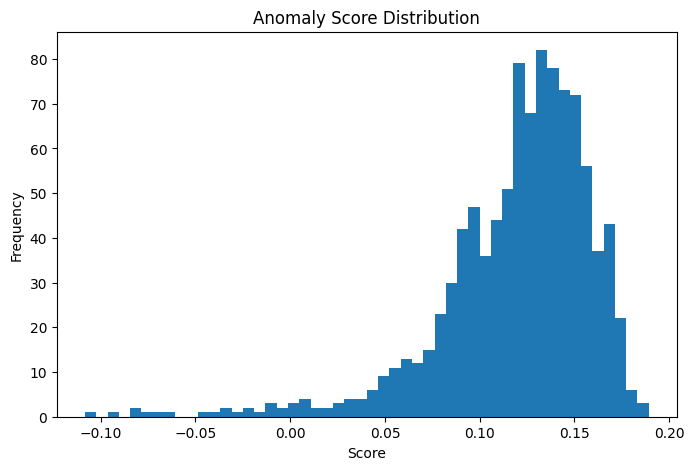

In [10]:
plt.figure(figsize=(8,5))
plt.hist(data['anomaly_score'], bins=50)
plt.title("Anomaly Score Distribution")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()

#### Save Output

In [11]:
data.to_csv("../Dataset/anomaly_output.csv", index=False)
print("Anomaly results saved ✅")

Anomaly results saved ✅
